## Visualizing 2D pose attributes
To run this notebook you first have to generate the `toy_dataset` which can be generated by executing `make toy_dataset`

In [1]:
import json  # Used to read the dataset file
import cv2  # Used to read the images
import matplotlib.pyplot as plt  # Used to plot
%matplotlib inline

### Read the dataset file

In [2]:
# Read the dataset index file
with open('../data/toy_dataset/blendgen_dataset.json') as json_file:
    data = json.load(json_file)

### Read the image file

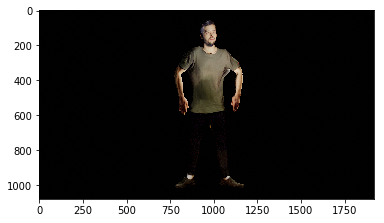

In [3]:
# The frame of the dataset we will use for visualization
FRAME_NUM = 5

# Plot the color image
color = cv2.cvtColor(cv2.imread('../data/toy_dataset/color/Image{:0>4}.png'.format(FRAME_NUM)), cv2.COLOR_RGB2BGR)
plt.imshow(color)
plt.show()

### Draw screen-space pose over image

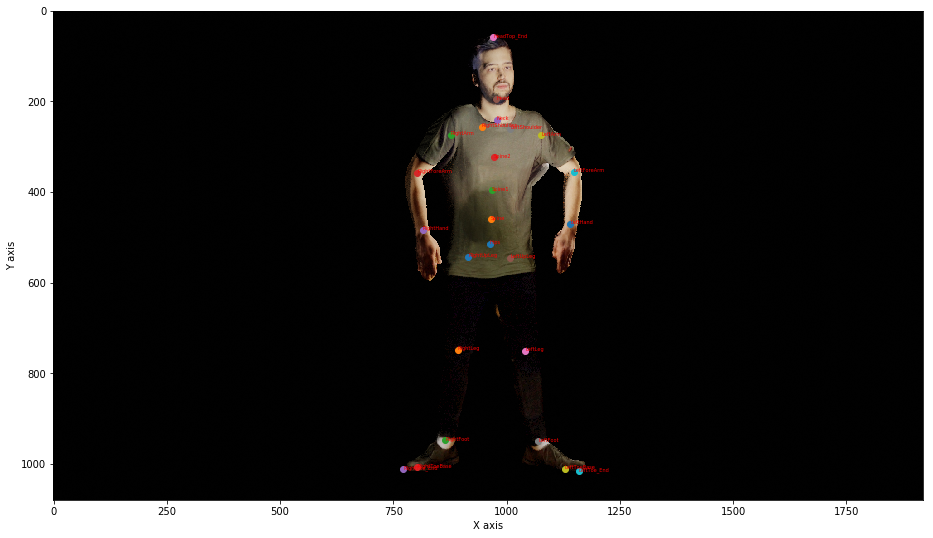

In [4]:
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')

# Draw the color image
plt.imshow(color)

"""
Iterate over all joints and draw the points
The reason we use [1:] at the end is because toy_dataset
stores the bounding box in location [0] of the attributes
list and we only want to draw the skeleton
"""
for joint in data['data'][FRAME_NUM]['attributes'][1:]:
    joint_pos = next(iter(joint.values()))
    joint_names = next(iter(joint.keys()))
    ax.scatter(joint_pos[0], joint_pos[1])
    ax.text(joint_pos[0], joint_pos[1], '%s' % (str(joint_names.split(':')[1])), size=5, zorder=1,  
 color='r')
    
plt.show()